In [1]:
import numpy as np
from tqdm import trange, tqdm
import matplotlib.pyplot as plt


# Deprojection functions

In [2]:

################################ intrinsic parameters of Oblate daisk  ###############


def Disk_puq(theta=None, qobs=None, sigobs=None):
    
    theta_view=theta * (np.pi/180.0)
    qdisk1= (qobs**2- np.cos(theta_view)**2 )/(np.sin(theta_view)**2)
  
    if (qdisk1 > 0):
        qdisk2 = np.sqrt(qdisk1)       
    else:
        qdisk2 = 'unallowable qd'

    pd = 1
    sigm = sigobs
    return    qdisk2, pd, sigm


####################################### intrinsic parameters triaxial bar with twist #################
def triax_tpp2pqu(theta=None, phi=None, psi=None, qobs=None, psi_off=None, sigobs=None, res=None):
    """!@brief Function description.

    @details This routine is slow and sloppy, but correct. Written by RvdB. Moved to own file on 03/FEB/06.

    @param[in] input ...
    """
    res=1
    theta_view=theta * (np.pi/180.0)
    phi_view=phi * (np.pi/180.0)
    psi_obs=(psi+psi_off) * (np.pi /180.0)

    secth = 1.0/np.cos(theta_view)
    cotph = 1.0/np.tan(  phi_view)

    if abs(np.cos(theta_view)) < 1.0e-6 : res=0
    if abs(np.tan(phi_view  )) < 1.0e-6 : res=0

    delp = 1.0 - qobs ** 2

    nom1minq2 = delp * ( 2.0 *np.cos(2.0*psi_obs) + np.sin(2.0*psi_obs) * (secth*cotph - np.cos(theta_view) * np.tan(phi_view)))
    nomp2minq2 = delp * ( 2.0*np.cos(2.0*psi_obs) + np.sin(2.0*psi_obs) * (np.cos(theta_view)*cotph - secth*np.tan(phi_view)))
    denom  = 2.0*np.sin(theta_view)** 2*( delp*np.cos(psi_obs)* (np.cos(psi_obs) + secth*cotph*np.sin(psi_obs)) - 1.0 )

    if np.max(np.abs(denom)) < 1.0e-6 : res=0

    # These are temporary values of the squared intrinsic axial
    # ratios p^2 and q^2
    qintr = (1.0 - nom1minq2 /denom)
    pintr = (qintr + nomp2minq2/denom)
    # Quick check to see if we are not going to take the sqrt of
    # a negative number.
    if ((np.min(qintr) < 1.0e-6)| (np.min(pintr) <= 1.0e-6)) : res=0

    # intrinsic axial ratios p and q
    qintr = np.sqrt(qintr)
    pintr = np.sqrt(pintr)

    # triaxiality parameter T = (1-p^2)/(1-q^2)
    triaxpar=(1.0-pintr** 2)/(1.0-qintr**2 )
    if ( np.max(triaxpar) > 1.0 ) : res=0
    if ( np.min(triaxpar) < 0.0 ): res=0
    if ( np.max(qintr - pintr ) > 0): res=0
    if ( np.min(qintr) <= 0.0 ) : res=0


    if (res == 1):
        pintr2= pintr
        qintr2= qintr
        uintr2=1.0/(np.sqrt( qobs/np.sqrt((pintr*np.cos(theta_view))**2+
                                          (qintr*np.sin(theta_view))**2*((pintr*np.cos(phi_view))**2 +
                                                                        np.sin(phi_view)**2))))
        sigm=(sigobs/uintr2)
        uintr3= np.sqrt(uintr2)
    else:
        pintr2= 'unallowable p'
        qintr2= 'unallowable q'
        sigm= 'unallowable u'
        uintr3 = 'unallowable u'

    
    return  pintr2, qintr2, uintr3 


####################################### check boundary ###############

############################## search for angles (intersection of all gaussians) #################
def serch_angle(cc=None, th1=None, th2=None, ph1=None , ph2=None, ps1=None ,ps2=None):

        if (cc==0):
            ian1,ian2   = th1,th2           #inclination
            phan1,phan2 = ph1,ph2         # phi
            ban1,ban2   = ps1,ps2          # bar angle or twist 90 + bar angle

        if (cc==1):  # full
            ian1,ian2   = 0,179  
            phan1,phan2 = -90,90
            ban1,ban2   = 0,180 


        # finding angels
        #===================================================
        disk_th=[]
        angle_th = []

        for n in range(0,len(qod)):

            angle_th2 = []            
            for i in range(ian1,ian2):
                qdisk1, pdisk1, sdisk1 = Disk_puq(theta=i, qobs=qod[n], sigobs=siod[n])
                
                if (qdisk1 != 'unallowable qd' ):
                    if (n == 0):
                        angle_th.append(i)
                    if (n > 0):
                        angle_th2.append(i)
                        
            if (n==1):
                disk_th = list(set(angle_th).intersection(set(angle_th2)))           
            if (n>1):
                disk_th = list(set(angle_th2).intersection(set(disk_th)))


        print (np.sort(disk_th) )   
        print ('=====================')
        print ('result=',len(disk_th))
        #============================== (twist Bar) ==============

        angle_thetab = []
        angle_phib = []
        angle_psib= []
        final=[]
        langle_thetab = []
        langle_phib = []
        langle_psib= []


        for m in tqdm(range(0,len(psi2))):

            angle_thetab2=[]
            angle_phib2=[]
            angle_psib2=[]
            for i in range(ian1,ian2):
                for j in range(phan1,phan2):
                    for k in range(ban1,ban2):
                        if (k >= 0 ):    # for negetive and positive psi delta psi also need to be different
                            pintr2, qintr2, uintr2 = triax_tpp2pqu(theta=i, phi=j, psi=k, qobs=qob[m], \
                                                               psi_off=psi2[m],  sigobs=siob[m], res=1)
                        if (k < 0 ):
                            pintr2, qintr2, uintr2 = triax_tpp2pqu(theta=i, phi=j, psi=k, qobs=qob[m], \
                                                               psi_off=psi2[m],  sigobs=siob[m], res=1)
                            
                        if (pintr2 != 'unallowable p' and qintr2 != 'unallowable q' and uintr2 != 'unallowable u' ):
                            if (m == 0):
                                angle_thetab.append(i)
                                angle_phib.append(j)
                                angle_psib.append(k)
                            if (m > 0):
                                angle_thetab2.append(i)
                                angle_phib2.append(j)
                                angle_psib2.append(k)
                            if (m == len(psi2)-1):  # crab the last gaussian
                                langle_thetab.append(i)
                                langle_phib.append(j)
                                langle_psib.append(k)     

            lfinal_angelb = list(zip(langle_thetab, langle_phib, langle_psib))
            final_angelb = list(zip(angle_thetab, angle_phib, angle_psib))
            final_angelb2 = list(zip(angle_thetab2, angle_phib2, angle_psib2))
            if (m==1):
                final = list(set(final_angelb2).intersection(set(final_angelb)))
            if (m>1):
                final = list(set(final_angelb2).intersection(set(final)))

        print ('=====================')
        print ('angles of bar=',len(final))

        #==================== find same angles between disk and bar ==============
        tri_result=[]
        for i in range(len(final)):
            if set(final[i][0:1]).intersection(set(disk_th)):
                tri_result.append(final[i][0:3])
       
        print ('=====================')
        print ('same angles for whole gaussians=',len(tri_result))

        return np.array(lfinal_angelb), np.array(final), np.array(tri_result)


    
############################## Add constraints #############    
def add_constraint(lg=None, b=None, h=None, incl=None,ibar=None, dif=None, first_dk=None ,last_bg=None):

        #========================================= all bulge angle 
        print ('=====================')
        print ('allowed angles for bulge =',len(b[:,0]))  


        #=============================================allowed for all for all
        print ('=====================')
        print (' allowed angles for bulge + disk =',len(h[:,0]))  


        #===================================== first constraint
        ftheta=[]
        fphi=[]
        fpsi=[]

        for i in range(0,len(h[:,0])):
            if (np.abs(int(h[i,2])-(ibar))<= 10 ): 
                ftheta.append(h[i,0]) 
                fphi.append(h[i,1])
                fpsi.append(h[i,2])

        print ('=====================')
        print ('position angle constraint =' ,len(ftheta))         
        #====================================== secound cons       

        ftheta2=[]
        fphi2=[]
        fpsi2=[]

        for i in range(0,len(ftheta)):
            if (np.abs(int(ftheta[i])-incl)<= 10 or np.abs(int(ftheta[i])-(180-incl))<= 10 ) : 
                ftheta2.append(ftheta[i]) 
                fphi2.append(fphi[i])
                fpsi2.append(fpsi[i]) 

        print ('=====================')        
        print ('inclination angle constraint =' ,len(ftheta2))          
        #================================= tirth
        first_dk = first_dk
        last_bg = last_bg
        ftheta3=[]
        fphi3=[]
        fpsi3=[]
        final_co = []

        for i in range(0,len(ftheta2)):
                qdisk1, pdisk1, sdisk1 = Disk_puq(theta=int(ftheta2[i]),  qobs=qod[first_dk], \
                                                  sigobs=siod[first_dk])
                
                pbar1, qbar1, sbar1  = triax_tpp2pqu(theta=int(ftheta2[i]), phi=int(fphi2[i]),\
                                                     psi=int(fpsi2[i]), qobs=qob[last_bg], \
                                                     psi_off=psi2[last_bg], sigobs=siob[last_bg], res=1)
                
                if ( abs(qdisk1*sdisk1 - qbar1*(siob[last_bg]/sbar1) )<= dif*(qbar1*(siob[last_bg]/sbar1)) ):
                    ftheta3.append(ftheta2[i])
                    fphi3.append(fphi2[i])
                    fpsi3.append(fpsi2[i])


        print ('=====================')
        print ('thickness constraint =' ,len(ftheta3)) 

        final_co = list(zip(ftheta3, fphi3, fpsi3))
        print (final_co) 
        
        #===================  print intrinsic for final angles    ===========================
        q_diskf, p_diskf, s_diskf = [],[],[]
        p_barf, q_barf, s_barf = [],[],[]
        for k in final_co:

                q_diskf, p_diskf, s_diskf = [],[],[]
                for n in range(0,len(qod)):
                    q_disk1, p_disk1, s_disk1 = Disk_puq(theta=k[0], qobs=qod[n], sigobs=siod[n])
                    p_diskf.append(p_disk1)
                    q_diskf.append(float("%.2f"% q_disk1))
                    s_diskf.append( float( "%.2f"% (1.0)) ) #s_disk1

                p_barf, q_barf, s_barf = [],[],[]
                for n in range(0,len(qob)) :
                    pbar1, qbar1, sbar1  = triax_tpp2pqu(theta=int(k[0]), phi=int(k[1]), psi=int(k[2]), qobs=qob[n], psi_off=psi2[n], sigobs=siob[n], res=1)
                    p_barf.append(float("%.2f"% pbar1))
                    q_barf.append(float("%.2f"% qbar1))
                    s_barf.append( float( "%.2f"% sbar1) ) #(siob[n]/sbar1)
                print ('')
                print ('#========'+str(k)+'=======')

                print ('')
                print ('pd=', p_diskf)
                print ('qd=', q_diskf)
                print ('ud=', s_diskf)
                print ('')

                print ('')
                print ('pb=', p_barf)
                print ('qb=', q_barf)
                print ('ub=', s_barf)
                print ('')

        ###########3
        print('###### angle space #######')
        print( 'theta = ', np.min(ftheta2) , np.max(ftheta2) )
        print( 'phi   = ', np.min(fphi2) , np.max(fphi2) )
        print( 'psi   = ', np.min(fpsi2) , np.max(fpsi2) ) 
            
    
    

# MGE fit out puts are copied here

In [3]:
# Bar MGE fit output
lob   = np.array([86.526, 2589.597, 3208.055, 23213.942, 14871.641])
lob_pc= np.array([3704.801, 8404.87, 2675.332, 439.306, 43.923])
siob  = np.array([0.294, 1.069, 2.119, 18.296, 45.0])
qob   = np.array([0.99, 0.99, 0.981, 0.58, 0.614])
psi2  = np.array([-59., -59., -66., -63.8305, -59.6108])
# NOTE that these Psi should be calculate with respect to the disk PA

# disk MGE fit output
lod    = np.array([2092.712, 10661.672, 18523.706, 3963.937, 12219.925, 21604.193, 54243.93, 34744.563])
lod_pc = np.array([3149.241, 3343.404, 2054.372, 147.203, 504.083, 177.944, 124.066, 25.73])
siod   = np.array([2.343, 5.112, 8.667, 11.512, 14.211, 31.804, 60.354, 106.066])
qod    = np.array([0.575, 0.58, 0.57, 0.965, 0.57, 0.57, 0.57, 0.57])


lumarray_pc = np.concatenate((lob_pc,lod_pc))
sigmasec    = np.concatenate((siob,siod))   
qObs        = np.concatenate((qob,qod))

print(len(qObs))

13


In [55]:
parsec_km = 30856775810788.379
arcsec_km = 2005796578942549.0
upsilon   = 1.0

# surface brightness in L_sun/km^2
surf_km = ( lumarray_pc/parsec_km**2 ) * upsilon
sigobs_km = sigmasec*arcsec_km    

Mass = 2*np.pi*qObs*sigobs_km**2*surf_km
print('tot mass consideing M/L=1:', '%.2E' % sum(Mass))
Mass

tot mass consideing M/L=1: 2.42E+10


array([8.41680550e+06, 2.52449291e+08, 3.12868007e+08, 2.26443564e+09,
       1.44989965e+09, 2.63919129e+08, 1.34539897e+09, 2.33530757e+09,
       4.99802112e+08, 1.54056042e+09, 2.72379391e+09, 6.83899527e+09,
       4.38045854e+09])

# Allowed viewing angles of the bar+disk for deprojection
# Compute intrinsic parameters of each Gaussian

In [56]:
# searching angles
lg, b, h = serch_angle(cc=0, th1=59, th2=64, ph1=-14, ph2=0, ps1=88 ,ps2=92)
#lg, b, h = serch_angle(cc=1, th1=55, th2=65, ph1=40 , ph2=50, ps1=80 ,ps2=100)# add constraints
print('####### start constraint #####')

# incl represents the observational measurement of the inclination angle
# ibar is actually the bar Position Angle (PA) (NOT the bar angle, which is phi); we set it similar to the disk PA
# dif is the thickness difference between the bar and the disk; set it to a very large number to remove this constraint
# We can set it to 0.1 when the parameter space is large to reduce degeneracy (but this does not always work)
try:
    add_constraint(lg=lg, b=b, h=h, incl=60,ibar=90 ,dif =100000.0, first_dk=1,last_bg=len(qob)-1)  # dif =0.1 first_dk=5 paper
except:
    print('No vewing angels !')



[59 60 61 62 63]
result= 5


  0%|                                                                                                                 | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_1427581/3259611056.py:55: RuntimeWarning: invalid value encountered in sqrt
  qintr = np.sqrt(qintr)
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 50.47it/s]

angles of bar= 37
same angles for whole gaussians= 37
####### start constraint #####
allowed angles for bulge = 37
 allowed angles for bulge + disk = 37
position angle constraint = 37
inclination angle constraint = 37
thickness constraint = 37
[(59, -12, 89), (60, -11, 88), (62, -12, 91), (62, -10, 88), (60, -11, 91), (59, -11, 90), (61, -11, 90), (63, -10, 88), (61, -10, 89), (63, -10, 91), (62, -11, 89), (59, -12, 91), (60, -12, 91), (60, -11, 90), (60, -10, 88), (62, -10, 90), (61, -11, 89), (61, -12, 91), (61, -10, 88), (63, -11, 91), (59, -11, 89), (63, -10, 90), (62, -11, 91), (59, -12, 90), (59, -13, 91), (60, -11, 89), (63, -9, 88), (60, -12, 90), (62, -10, 89), (61, -12, 90), (59, -11, 88), (63, -10, 89), (61, -11, 88), (60, -13, 91), (63, -11, 90), (61, -11, 91), (62, -11, 90)]

#========(59, -12, 89)=======

pd= [1, 1, 1, 1, 1, 1, 1, 1]
qd= [0.3, 0.31, 0.28, 0.95, 0.28, 0.28, 0.28, 0.28]
ud= [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


pb= [0.96, 0.96, 0.94, 0.35, 0.38]
qb= [0

# making 3D density

In [57]:
import agama

def getDensityParamsMGE(mass, Sx, Sy, Sz):
    '''
    return a dictionary containing parameters for creating agama.Density object
    corresponding to a single Gaussian component of an MGE
    '''
    return dict( \
        density = 'Spheroid',
        axisRatioY  = Sy/Sx,
        axisRatioZ  = Sz/Sx,
        scaleRadius = 1,
        gamma       = 0,
        beta        = 0,
        alpha       = 1,
        outerCutoffRadius = 2**0.5 * Sx,
        cutoffStrength = 2,
        densityNorm    = mass / ((2*np.pi)**1.5 * Sx * Sy * Sz) )


def makeDensityMGE(tab, distance, length_unit, p, q, u):
    '''
    Construct an agama.Density object corresponding to an axisymmetric MGE read from a text file
    and deprojected assuming the given inclination angle.
    '''
    arcsec2kpc = distance * np.pi / 648000   # conversion factor from arcseconds to kpc

    # construct a Density object from each component, and finally the total composite density
    components = [
        agama.Density(**getDensityParamsMGE(
            # for each Gaussian, the central surface density Sigma0 (1st column) expressed in Msun/pc^2
            # is converted to the total mass  M = 2 pi Sigma0 [pc/"]^2 L^2 q,
            # where L is the major axis length in arcsec, q is the axis ratio,
            mass = 2*np.pi * t[0] * (1000*arcsec2kpc * t[1])**2 * t[2],
            # convert scale radii in arcseconds into the model length units
            Sx   = (t[1]/t[5]) * (arcsec2kpc / length_unit),
            Sy   = (t[1]/t[5]) * (arcsec2kpc / length_unit) * t[3],   # two axes are identical
            Sz   = (t[1]/t[5]) * (arcsec2kpc / length_unit) * t[4])  # third is smaller
        ) for t in tab]
    return agama.Density(*components)

In [58]:
# MGE fit output
lumarray_pc = np.concatenate((lob_pc,lod_pc))  # L/pc2
sigmasec    = np.concatenate((siob,siod))      # arcsec
qObs        = np.concatenate((qob,qod))

#========(59, -11, 89)======= 

# disk intrinsic parameters
pd= [1, 1, 1, 1, 1, 1, 1, 1]
qd= [0.3, 0.31, 0.28, 0.95, 0.28, 0.28, 0.28, 0.28]
ud= [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

# bar intrinsic parameters
pb= [0.96, 0.96, 0.93, 0.35, 0.37]
qb= [0.95, 0.95, 0.93, 0.22, 0.12]
ub= [0.98, 0.98, 0.98, 0.76, 0.75]


pt = np.concatenate((pb,pd))
qt = np.concatenate((qb,qd))   
ut = np.concatenate((ub,ud))

#=======================
mge2 = np.column_stack((lumarray_pc, sigmasec, qObs, pt, qt, ut))

In [59]:
distance = 16.194 #MPC
z        = 0.003112      
scale    = 0.75
arcsec2kpc= distance * np.pi / 648000        # conversion factor (number of kiloparsecs in one arcsecond)
agama.setUnits(mass=1, length=1, velocity=1)

# make density object using AGAMA
densityStars = makeDensityMGE(mge2, distance, arcsec2kpc, pt, qt, ut)

# Computing potential
pot_stars = agama.Potential(type='CylSpline', density=densityStars, mmax=6, rmin=0.1, zmin=0.05, rmax=30.0, zmax=15.0)

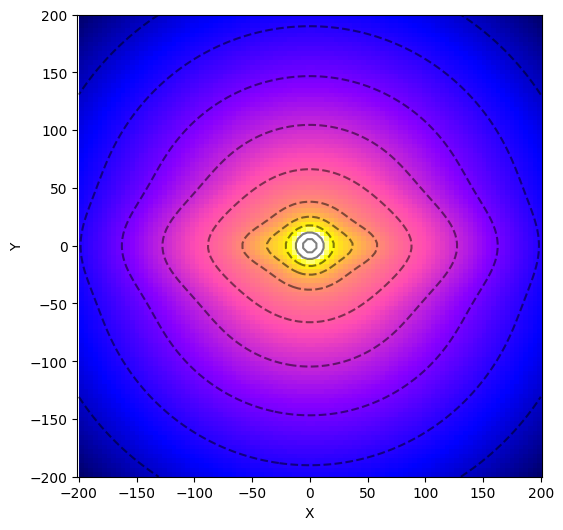

In [60]:
ex=200
x = np.linspace(-ex,ex, 100)
y = np.linspace(-ex,ex, 100)
z = np.linspace(-10,10, 100)

X1,Y1 = np.meshgrid(x,y)
X2,Z2 = np.meshgrid(x,z)
Z3,Y3 = np.meshgrid(z,y)

densxy = np.array([densityStars.density(x,y,0) for x,y in zip(np.ravel(X1), np.ravel(Y1))])
densxz = np.array([densityStars.density(x,0,z) for x,z in zip(np.ravel(X2), np.ravel(Z2))])
denszy = np.array([densityStars.density(0,y,z) for z,y in zip(np.ravel(Z3), np.ravel(Y3))])

#=============
l1,l2=-5,0

ax = plt.figure(figsize=(6, 6))
image=np.log10(densxy).reshape(X1.shape)
p = plt.imshow(image,origin='lower', aspect='auto',extent=[-ex, ex, -ex,ex],
          cmap='gnuplot2',  vmin=l1, vmax=l2)

plt.contour(image, levels=10, extent=[-ex, ex, -ex, ex], colors='black', alpha=0.5)
#cb = plt.colorbar(p, orientation='vertical',pad=.1)
#cb.set_label("$\mathrm{log_{10} \hspace{0.2cm} (\Sigma \hspace{0.1cm} [M_\odot pc^-2])}$")

plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal') 

plt.show()